In [17]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [18]:
load_dotenv()

True

In [19]:
model = ChatGoogleGenerativeAI(
    model = 'gemini-2.5-flash',
    temperature = 0
)

In [20]:
class BlogState(TypedDict):

    title : str
    outline : str
    content : str
    response : int

In [21]:
def create_outline(state:BlogState) -> BlogState:

    #fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    #update state
    state['outline'] = outline

    return state

In [22]:
def create_blog(state:BlogState) -> BlogState:
    
    title = state['title']
    outline = state['outline']

    prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [23]:
def evaluate_blog(state: BlogState) -> BlogState:
    title = state['title']
    content = state['content']

    prompt = f'based on the title {title} and the content {content} evaluate the content on a scale of 10. Reply with only a single integer number, nothing else.'

    response = model.invoke(prompt).content

    state['response'] = int(response.strip())  

    return state


In [24]:
graph = StateGraph(BlogState)

graph.add_node('create_outline' , create_outline)
graph.add_node('create_blog' , create_blog)
graph.add_node('evaluate_blog' , evaluate_blog)

In [25]:
graph.add_edge(START , 'create_outline')
graph.add_edge('create_outline' , 'create_blog')
graph.add_edge('create_blog' , 'evaluate_blog')
graph.add_edge('evaluate_blog', END)



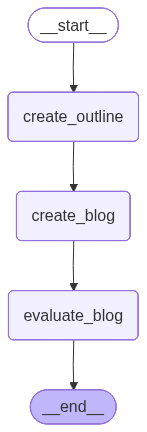

In [26]:
graph.compile()

In [27]:
workflow = graph.compile()

In [28]:
Initial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(Initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.\n\n---\n\n## Blog Title Options:\n\n*   **The AI Awakening: India\'s Rapid Rise in Artificial Intelligence**\n*   **From Niche to National Imperative: Unpacking India\'s AI Revolution**\n*   **India\'s AI Ascent: A Transformative Journey Shaping the Future**\n*   **Beyond the Hype: How India is Becoming an AI Powerhouse**\n\n---\n\n## Detailed Blog Outline: The AI Awakening: India\'s Rapid Rise in Artificial Intelligence\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Catchy Hook:** Start with a compelling statistic, a thought-provoking question, or a vivid image of AI\'s impact globally, then pivot to India.\n    *   *Example:* "From self-driving cars to personalized healthcare, Artificial Intelligence is reshaping our world at an unprecedented pace. But while Silicon Valley often grabs the headlines, 

In [29]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be comprehensive, engaging, and informative.

---

## Blog Title Options:

*   **The AI Awakening: India's Rapid Rise in Artificial Intelligence**
*   **From Niche to National Imperative: Unpacking India's AI Revolution**
*   **India's AI Ascent: A Transformative Journey Shaping the Future**
*   **Beyond the Hype: How India is Becoming an AI Powerhouse**

---

## Detailed Blog Outline: The AI Awakening: India's Rapid Rise in Artificial Intelligence

### I. Introduction (Approx. 150-200 words)

*   **A. Catchy Hook:** Start with a compelling statistic, a thought-provoking question, or a vivid image of AI's impact globally, then pivot to India.
    *   *Example:* "From self-driving cars to personalized healthcare, Artificial Intelligence is reshaping our world at an unprecedented pace. But while Silicon Valley often grabs the headlines, a quiet yet powerful AI revolution is unfolding in a nation poised to

In [30]:
print(final_state['content'])

## The AI Awakening: India's Rapid Rise in Artificial Intelligence

From self-driving cars to personalized healthcare, Artificial Intelligence is reshaping our world at an unprecedented pace. While Silicon Valley often grabs the headlines, a quiet yet powerful AI revolution is unfolding in a nation poised to become a global leader: India. With its unique blend of a vast talent pool, burgeoning digital infrastructure, and an immense market ripe for innovation, India is rapidly transitioning from an AI adopter to an AI innovator. This blog post will delve into the driving forces behind India's AI ascent, explore the key sectors embracing this transformative technology, highlight India's unique contributions, acknowledge the challenges, and cast a vision for its future as a global AI powerhouse.

### The Driving Forces: Why India is Ripe for AI

India's journey to becoming an AI leader is propelled by a confluence of strategic initiatives and inherent strengths.

**A. Government Initiativ

In [31]:
print(final_state['response'])

9
